In [7]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

In [8]:
n_samples = 1000

X, y = make_circles(
    n_samples = n_samples,
    noise = 0.03,
    random_state=42
)

X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [9]:
import pandas as pd 
circles = pd.DataFrame({"x1": X[:,0], "X2": X[:,1], "label": y})

circles.head() # shows first 5 rows by default

,x1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [10]:
circles.label.value_counts()

,count
label,
1,500
0,500


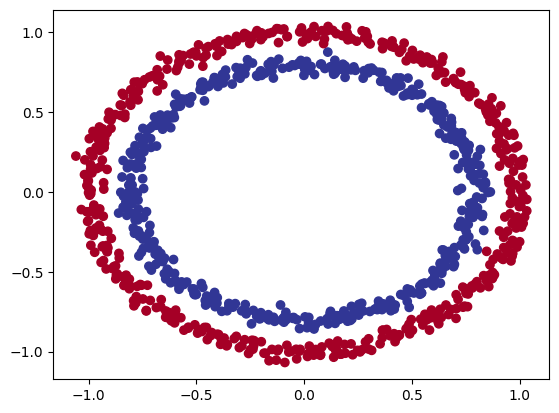

In [11]:
# Visualize with a plot
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, # c stands for color so here we are telling it color each class differently 
            cmap=plt.cm.RdYlBu);

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [13]:
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

x_train = x_train.to(device)
x_test = x_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

print(X.shape, y.shape)
print(len(x_train), len(y_train) , len(x_test), len(y_test))

torch.Size([1000, 2]) torch.Size([1000])
800 800 200 200


In [14]:
X_sample = X[0]
y_sample = y[0]

X_sample , y_sample


(tensor([0.7542, 0.2315]), tensor(1.))

In [15]:
class modelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # as in our dataset we only have 2 features right, with the help of those 2 features nn  layer 1 generates 3 more that becomes 5 features and it is then passed to next layer that is (layer 2)
        self.layer_2 = nn.Linear(in_features=5, out_features=1) 
        
    def forward(self, x: torch.Tensor):
        return self.layer_2(self.layer_1(x)) # here you can see computation goes from layer 1 to layer 2, layer 1 output is forwarded to layer 2. Amazing!!
    
modelV0 = modelV0().to(device) # here we initialize the model by creating an instance of it. The reason of initializing model on gpu is to make it computation to work on gpu as these layer 1 and 2 contains weights and biases (tensors essentially).

# here on top - bottom you can see we have created 2 neural networks that works in a same way but approach is different, one is highly customizable, whereas other is in less control over.

In [16]:
sequential_model_V0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)


# let's makes some prediction on untrained model

In [17]:
print(X.dtype, y.dtype)

untrained_preds_modelV0 = modelV0(x_test.to(device)) # these are y logits only since no activation function here.
# untrained_preds_modelV0 = sequential_model_V0(x_test.to(device))

print("Actual and predicted tensor shape: ", untrained_preds_modelV0.shape)
print("First 5 untrained predictions: ", untrained_preds_modelV0[:5])
print("First 5 actual predictions: ", y_test[:5])

torch.float32 torch.float32
Actual and predicted tensor shape:  torch.Size([200, 1])
First 5 untrained predictions:  tensor([[-0.5383],
        [-0.6784],
        [-0.2424],
        [-0.6219],
        [-0.3555]], grad_fn=<SliceBackward0>)
First 5 actual predictions:  tensor([1., 0., 1., 0., 1.])


In [18]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=modelV0.parameters(), lr=0.1)

In [19]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [20]:
y_pred_prob = torch.sigmoid(untrained_preds_modelV0) # here we are converting raw logits to probabilities
y_pred_prob[:5]

tensor([[0.3686],
        [0.3366],
        [0.4397],
        [0.3494],
        [0.4120]], grad_fn=<SliceBackward0>)

In [21]:
y_preds = torch.round(y_pred_prob) # now we are actually getting y preds from pred probabilities
y_pred_labels = torch.round(torch.sigmoid(untrained_preds_modelV0)) # in a single line
y_pred_labels.squeeze()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

# Now let's do training

In [22]:
print(x_train.device)
print(y_train.device)

torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    modelV0.train()
    
    training_predictions_logits = modelV0(x_train).squeeze()
    training_predictions_labels = torch.round(torch.sigmoid(training_predictions_logits))

    loss = loss_fn(training_predictions_logits,y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=training_predictions_labels)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}%")
    
    



cpu
cpu
Epoch: 0 | Loss: 0.72400, Accuracy: 50.00%
Epoch: 10 | Loss: 0.70518, Accuracy: 48.88%
Epoch: 20 | Loss: 0.69898, Accuracy: 45.25%
Epoch: 30 | Loss: 0.69666, Accuracy: 47.50%
Epoch: 40 | Loss: 0.69566, Accuracy: 48.00%
Epoch: 50 | Loss: 0.69514, Accuracy: 48.25%
Epoch: 60 | Loss: 0.69482, Accuracy: 48.38%
Epoch: 70 | Loss: 0.69460, Accuracy: 48.75%
Epoch: 80 | Loss: 0.69442, Accuracy: 49.12%
Epoch: 90 | Loss: 0.69427, Accuracy: 49.25%


In [23]:
trainied_model_preds = torch.round(torch.sigmoid(modelV0(x_test))).squeeze()
trainied_model_preds[:5], y_test[:5] 

(tensor([0., 0., 1., 0., 1.], grad_fn=<SliceBackward0>),
 tensor([1., 0., 1., 0., 1.]))

In [24]:
import numpy as np
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})



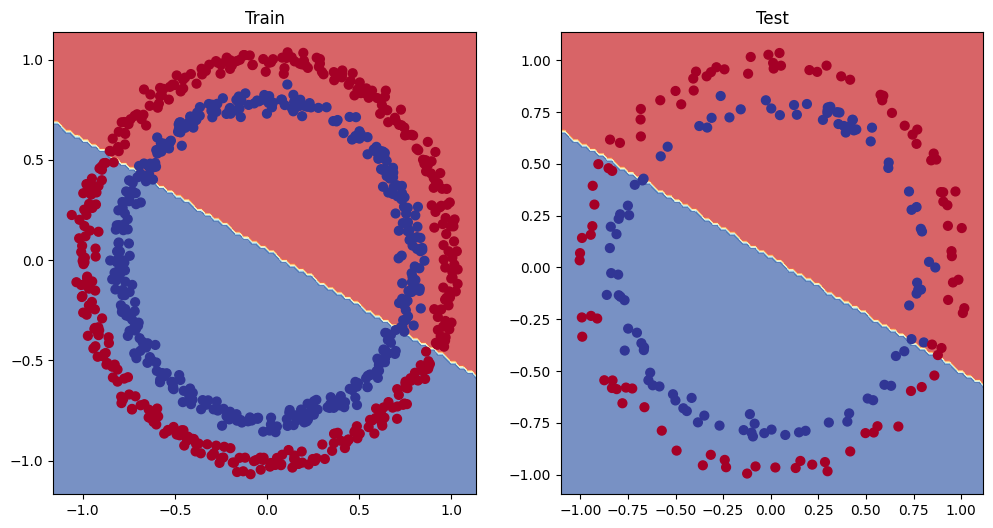

In [25]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV0, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV0, x_test, y_test)

# So above you can see our model is not working well, lets try with another model, with better hyper parameters

In [26]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=100)
        self.layer_3 = nn.Linear(in_features=100,out_features=800)
        self.layer_4 = nn.Linear(in_features=800,out_features=1)
        self.relu = nn.ReLU()
        
        
    def forward(self, x: torch.Tensor):
        # return self.layer_4(self.layer_3(self.layer_2(self.layer_1(x))))
        return self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))

modelV1 = CircleModelV1().to(device)
print(modelV1)
print("device:", device)
print("model:", next(modelV1.parameters()).device)

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=100, bias=True)
  (layer_3): Linear(in_features=100, out_features=800, bias=True)
  (layer_4): Linear(in_features=800, out_features=1, bias=True)
  (relu): ReLU()
)
device: cpu
model: cpu


tensor([0.0750, 0.0831, 0.0493, 0.0871, 0.0724, 0.0844, 0.0629, 0.0608, 0.0485,
        0.0830], grad_fn=<SqueezeBackward0>)
tensor([0.5187, 0.5208, 0.5123, 0.5218, 0.5181, 0.5211, 0.5157, 0.5152, 0.5121,
        0.5207], grad_fn=<SqueezeBackward0>)
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], grad_fn=<SqueezeBackward0>)


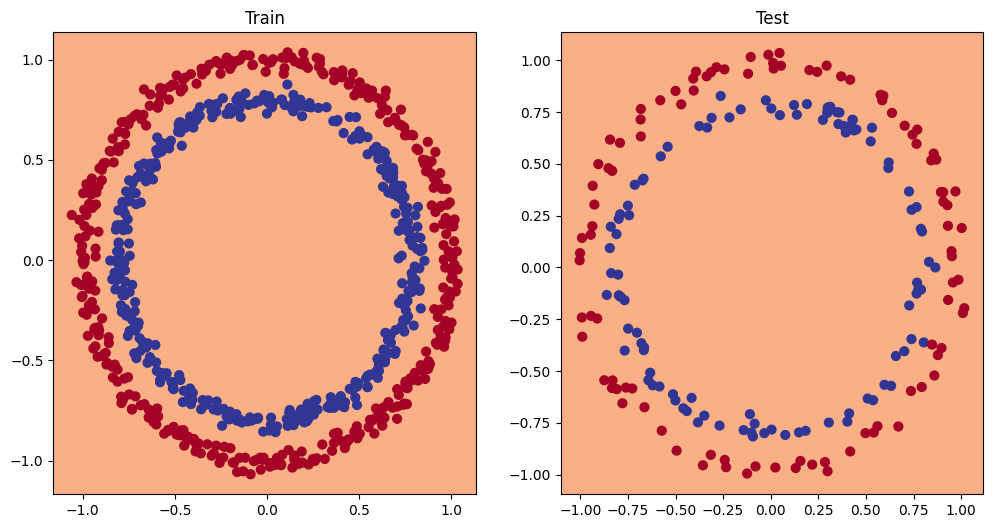

In [27]:
modelV1Logits = modelV1(x_test)
print(modelV1Logits[:10].squeeze())
modelV1PredictionsProb = torch.sigmoid(modelV1Logits)
print(modelV1PredictionsProb[:10].squeeze())
modelV1Labels = torch.round(modelV1PredictionsProb)
print(modelV1Labels[:10].squeeze())


# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV1, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV1, x_test, y_test)



In [28]:
non_linear_optimizer = torch.optim.SGD(params=modelV1.parameters(), lr=0.1)

In [29]:
print("device variable:", device)
print("x_train:", x_train.device)
print("y_train:", y_train.device)
print("model:", next(modelV1.parameters()).device)


print("x_shape:", x_train.shape)
print("y_shape:", y_train.shape)

torch.manual_seed(42)
epochs = 1500
modelV1.to(device)
for epoch in range(epochs):
    modelV1.train()
    
    modelV1TrainLogits = modelV1(x_train).squeeze()
    modelV1TrainLabels = torch.round(torch.sigmoid(modelV1TrainLogits))
    loss = loss_fn(modelV1TrainLogits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=modelV1TrainLabels)
    
    non_linear_optimizer.zero_grad()
    loss.backward()
    non_linear_optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}%")
    
    


device variable: cpu
x_train: cpu
y_train: cpu
model: cpu
x_shape: torch.Size([800, 2])
y_shape: torch.Size([800])
Epoch: 0 | Loss: 0.69463, Accuracy: 50.00%
Epoch: 10 | Loss: 0.69270, Accuracy: 59.50%
Epoch: 20 | Loss: 0.69148, Accuracy: 56.62%
Epoch: 30 | Loss: 0.69032, Accuracy: 56.12%
Epoch: 40 | Loss: 0.68915, Accuracy: 59.13%
Epoch: 50 | Loss: 0.68799, Accuracy: 60.88%
Epoch: 60 | Loss: 0.68680, Accuracy: 60.50%
Epoch: 70 | Loss: 0.68559, Accuracy: 59.88%
Epoch: 80 | Loss: 0.68434, Accuracy: 59.75%
Epoch: 90 | Loss: 0.68306, Accuracy: 59.88%
Epoch: 100 | Loss: 0.68176, Accuracy: 59.75%
Epoch: 110 | Loss: 0.68041, Accuracy: 59.38%
Epoch: 120 | Loss: 0.67901, Accuracy: 59.62%
Epoch: 130 | Loss: 0.67758, Accuracy: 59.62%
Epoch: 140 | Loss: 0.67610, Accuracy: 59.50%
Epoch: 150 | Loss: 0.67457, Accuracy: 59.13%
Epoch: 160 | Loss: 0.67299, Accuracy: 58.75%
Epoch: 170 | Loss: 0.67136, Accuracy: 58.50%
Epoch: 180 | Loss: 0.66967, Accuracy: 58.75%
Epoch: 190 | Loss: 0.66790, Accuracy: 58.

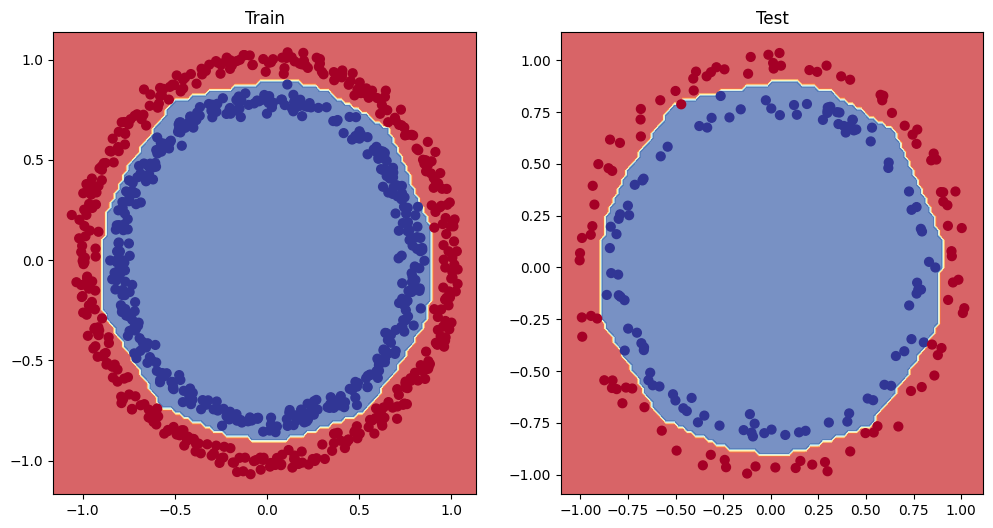

In [30]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(modelV1, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(modelV1, x_test, y_test)



In [31]:
modelV1.to(device)
modelV1TrainLogits = modelV1(x_test).squeeze()
modelV1TrainLabels = torch.round(torch.sigmoid(modelV1TrainLogits))

print(modelV1TrainLabels[:10])
print(y_test[:10])


tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], grad_fn=<SliceBackward0>)
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
# print(modelV1.state_dict())
print(list(modelV1.parameters()))

NameError: name 'model' is not defined